# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons',  'bau_redchrs', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'bau_gldbr', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}
# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='equitysilver',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_hv',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=2, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_hv')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=1., layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/equitysilver_c_curves_p.pkl
Loaded data from ./inputs/curves/equitysilver_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17063 rows, 83258 columns and 514878 nonzeros
Model fingerprint: 0xca29d094
Coefficient statistics:
  Matrix range     [5e-03, 6e+05]
  Objective range  [1e-01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 8690 rows and 17244 columns
Presolve time: 0.20s
Presolved: 8373 rows, 66014 columns, 477992 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.452e+05
 Factor NZ  : 3.254e+05 (roughly 30 MB of memory)
 Factor Ops : 1.477e+07 (less than 1 second per iteration)
 Threads    : 14

                  Objective                Residual
Iter       Primal  

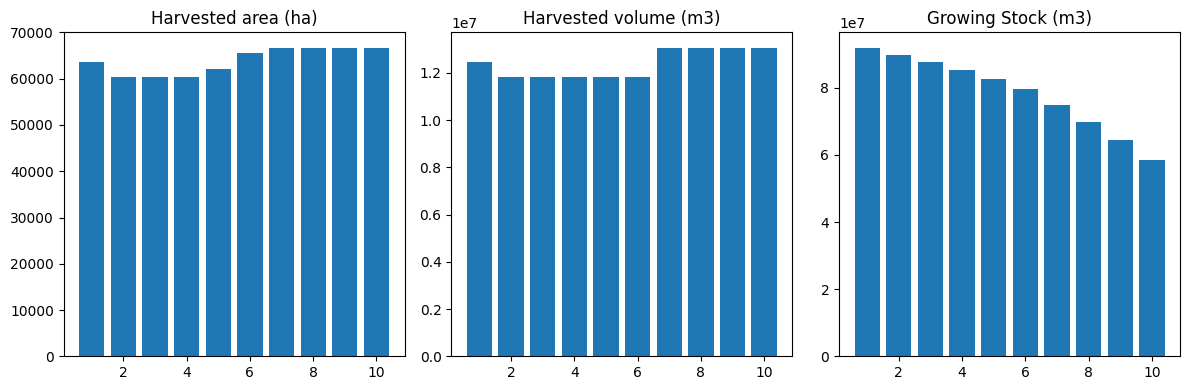

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_evenflow_cons_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  130901
The economic indicator (the provincial government revenues) is:  4464020
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


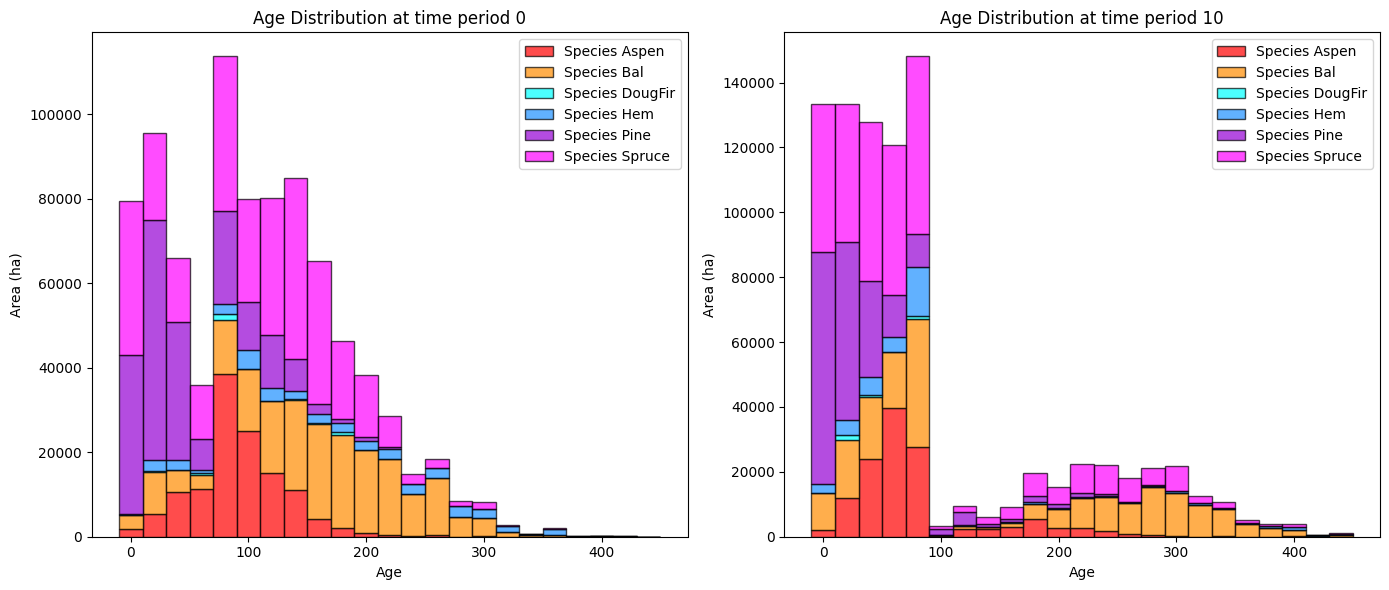

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6126.874563 -13025.252666
DougFir    947.047810    387.176384   -559.871426
Bal      59315.970469  79882.187655  20566.217186
Spruce   36410.744598  52548.704990  16137.960392
Aspen    29632.731169  20673.275932  -8959.455237
Pine      7432.733686   6721.590051   -711.143635

Old growth has **increased** by 13448.45 hectares from time period 0 to time period 10.


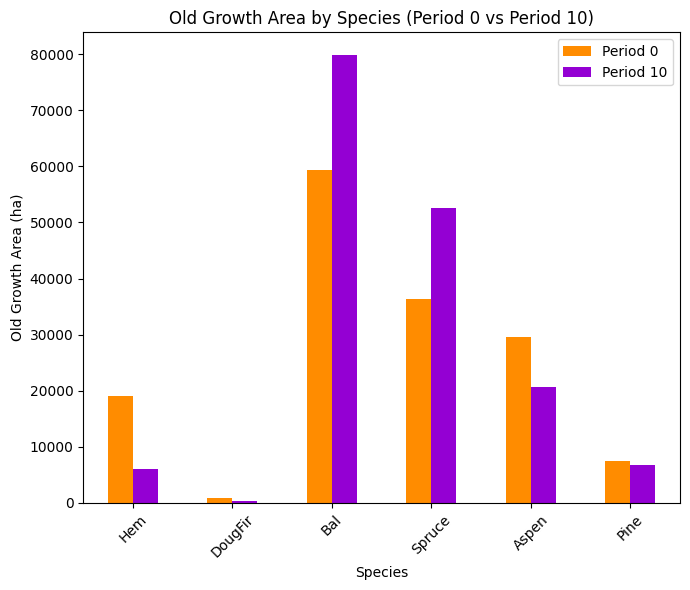

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7577

Diversity has **decreased** by 0.14% from time 0 to time 10.


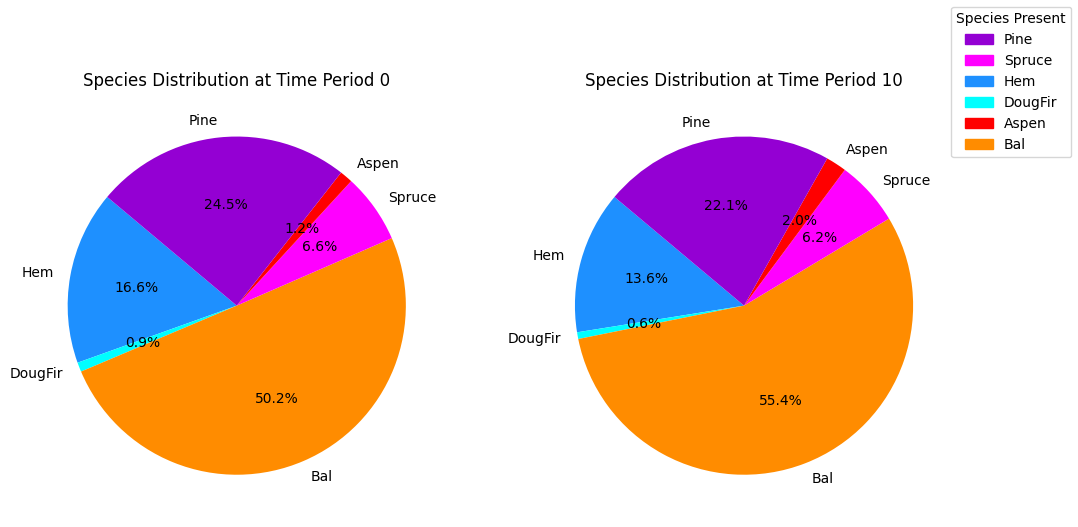

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_hv_evenflow_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x738aa7be
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [1e-01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8907 columns
Presolve time: 0.36s
Presolved: 8375 rows, 74352 columns, 536195 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

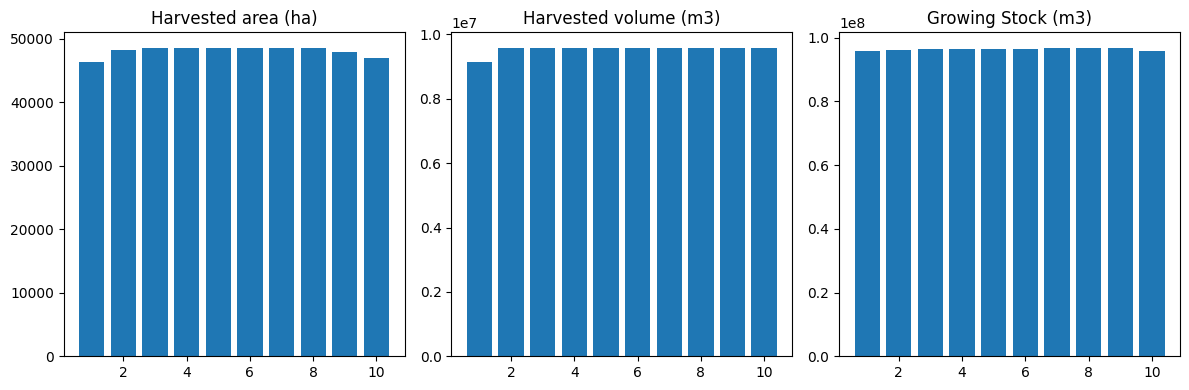

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  100842
The economic indicator (the provincial government revenues) is:  3438933
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


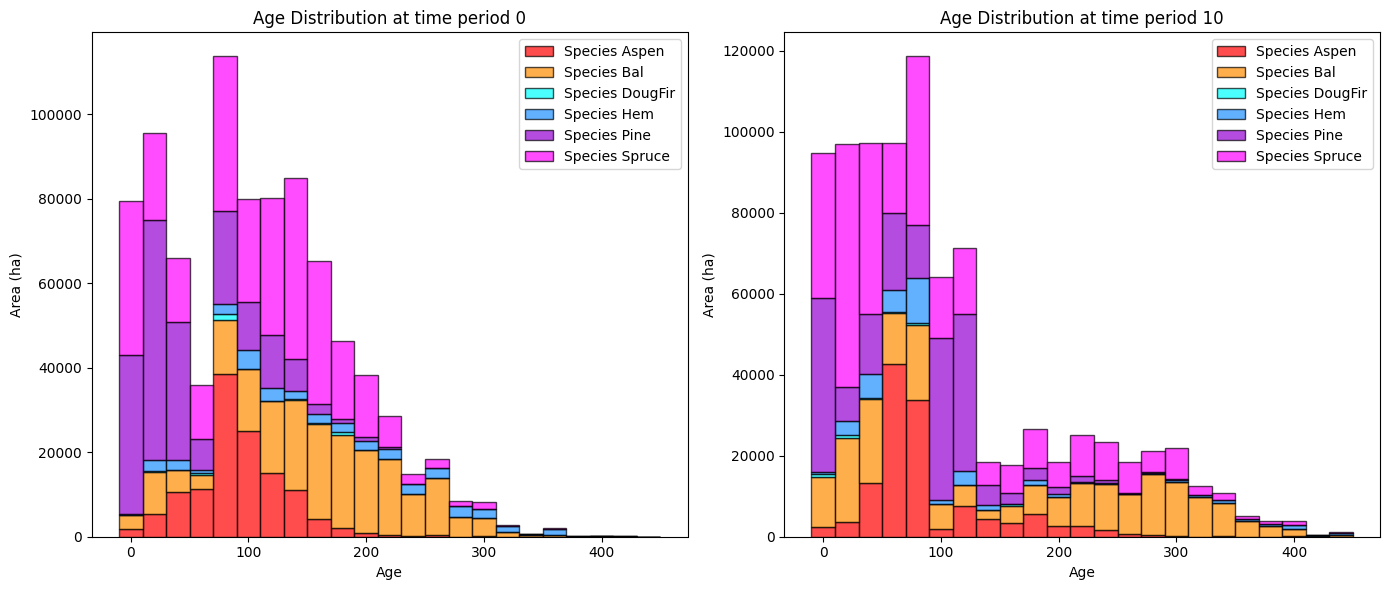

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   7867.427610 -11284.699619
DougFir    947.047810    656.427461   -290.620349
Bal      59315.970469  85384.032361  26068.061892
Spruce   36410.744598  58541.140685  22130.396087
Aspen    29632.731169  25732.222254  -3900.508915
Pine      7432.733686  17416.131995   9983.398309

Old growth has **increased** by 42706.03 hectares from time period 0 to time period 10.


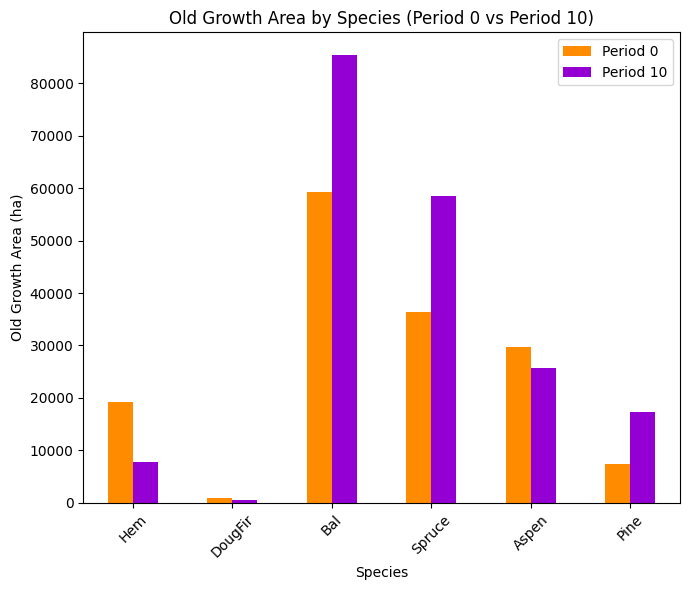

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7582

Diversity has **decreased** by 0.10% from time 0 to time 10.


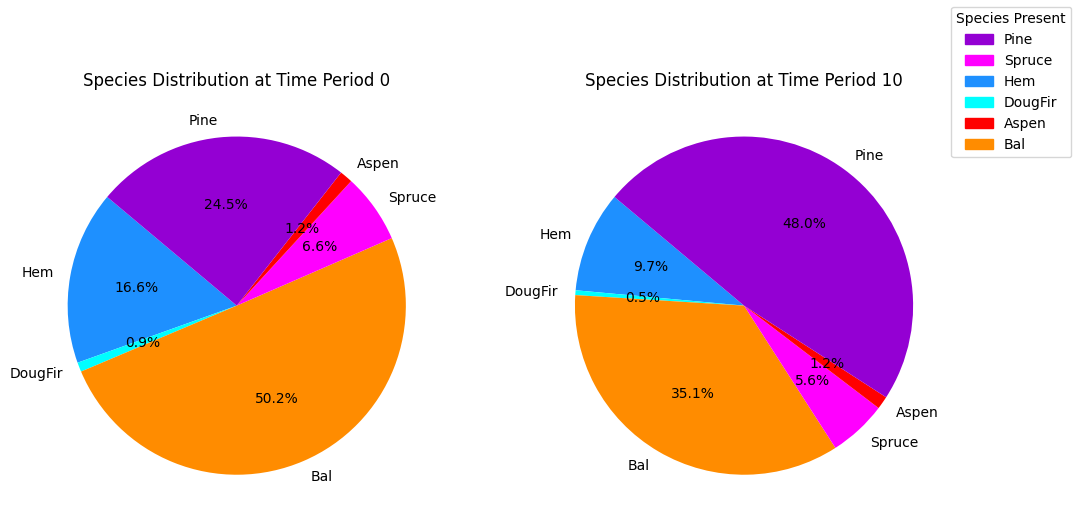

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_species_pie.pdf


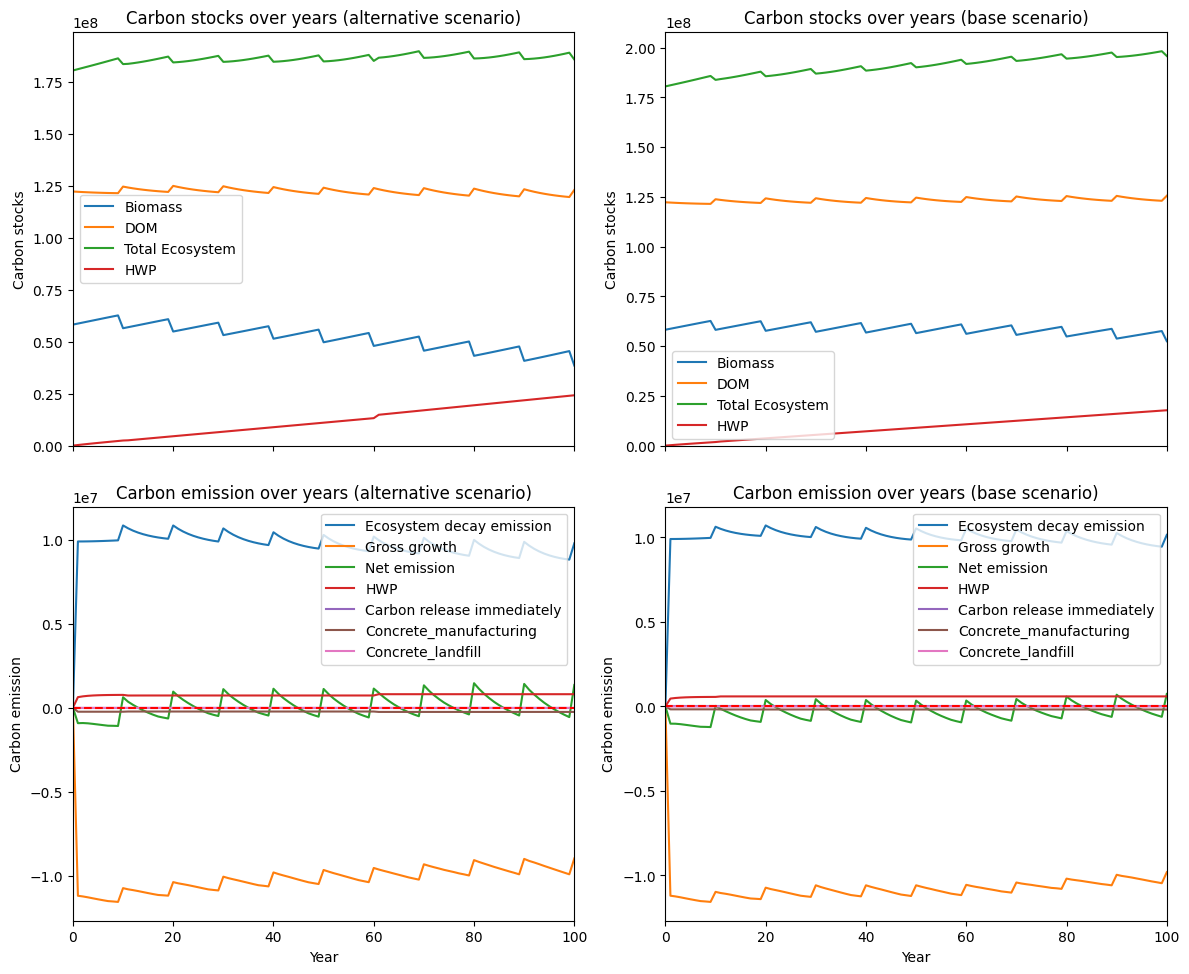

---------------------------------------------------------------------------------------
Net emission difference 46165209.59763579
Net emission base scenario -38521745.32493316
Net emission alternative scenario 7643464.272702625
dollar_per_ton is:  0.21661333474184247
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  -1740.553047  -1740.553047
DougFir  0.0   -269.251077   -269.251077
Bal      0.0  -5501.844706  -5501.844706
Spruce   0.0  -5992.435695  -5992.435695
Aspen    0.0  -5058.946322  -5058.946322
Pine     0.0 -10694.541944 -10694.541944

Overall, the old growth area has **decreased** by -29257.57 hectares in the alternative scenario compared to the base scenario.


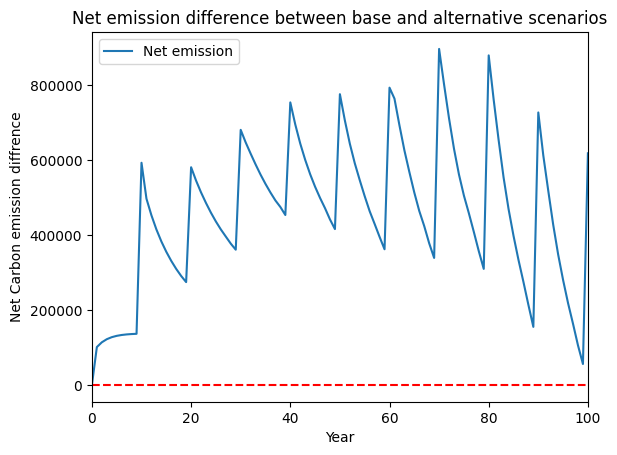

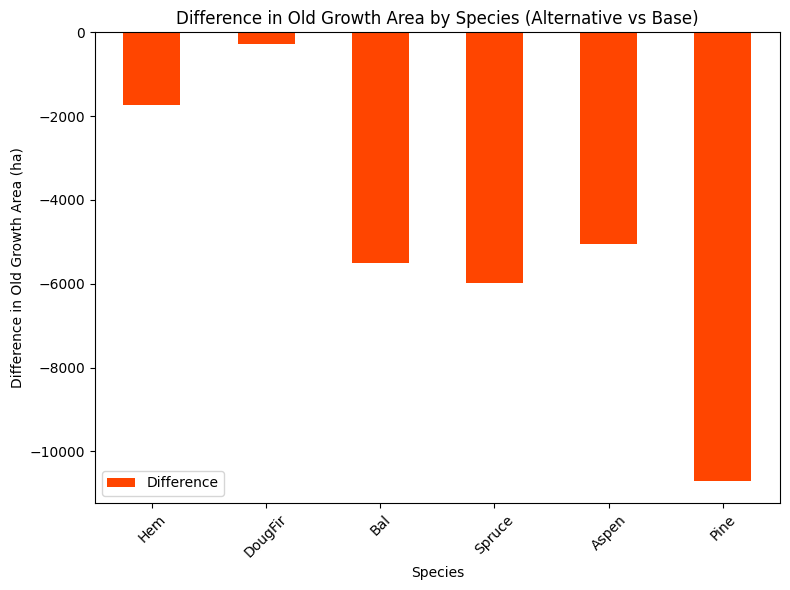

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_kpi_age_difference.pdf


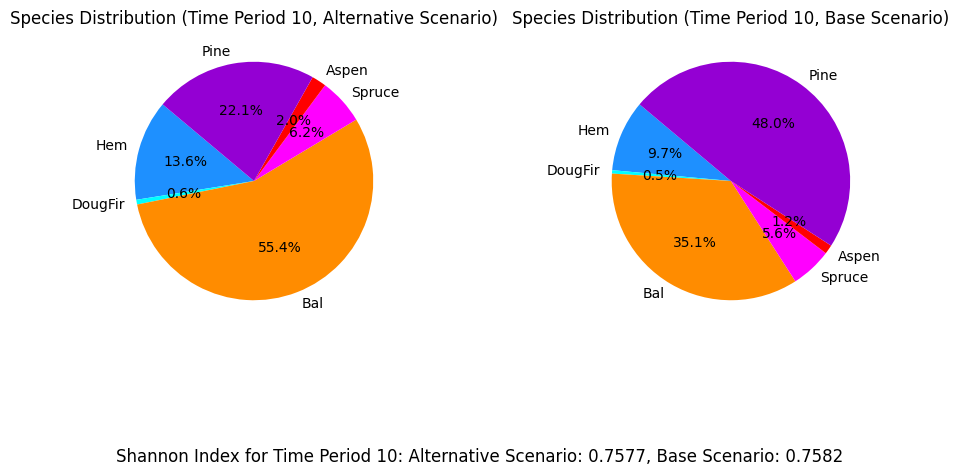

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_hv_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 33.8 minutes to run this script.


In [13]:
Start = time.time()

results_scenarios(fm, 
                  clt_percentage, 
                  credibility, 
                  budget_input, 
                  n_steps, 
                  max_harvest, 
                  scenario_name, 
                  displacement_effect, 
                  hwp_pool_effect_value, 
                  release_immediately_value, 
                  case_study, 
                  obj_mode,                   
                  pickle_output_base=False, 
                  pickle_output_alter=False)

print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

In [ ]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")